<a href="https://colab.research.google.com/github/Armin-HassanzadehHassanabad/Machine-Learning/blob/main/DecisionTreeClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import io
from google.colab import files

**Load and Inspect the Data**

In [ ]:
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))

NameError: name 'files' is not defined

In [ ]:
df.head()

NameError: name 'df' is not defined

**Define Features and Target**

In [ ]:
X = df.drop("c", axis=1)
y = df["c"]

NameError: name 'df' is not defined

**Handle Missing Values**

In [ ]:
X.fillna(0, inplace=True)

NameError: name 'X' is not defined

**Train/Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, Ytrain, Ytest = train_test_split(
    X, y, test_size=0.2, random_state=72
)

NameError: name 'X' is not defined

**Check Data Shapes**

In [ ]:
print(Xtrain.shape)
print(Xtest.shape)

NameError: name 'Xtrain' is not defined

**Train a Simple Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier()
DT.fit(Xtrain, Ytrain)
pred = DT.predict(Xtest)

**Quick Accuracy**

In [ ]:
(pred == Ytest).mean()

NameError: name 'pred' is not defined

**Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

acc  = accuracy_score(Ytest, pred)
rec  = recall_score(Ytest, pred)
pre  = precision_score(Ytest, pred)
fm   = f1_score(Ytest, pred)
conf = confusion_matrix(Ytest, pred)

print(acc, rec, pre, fm)
print(conf)

0.75 0.7291666666666666 0.6730769230769231 0.7
[[55 17]
 [13 35]]


**Visualizing the Tree**

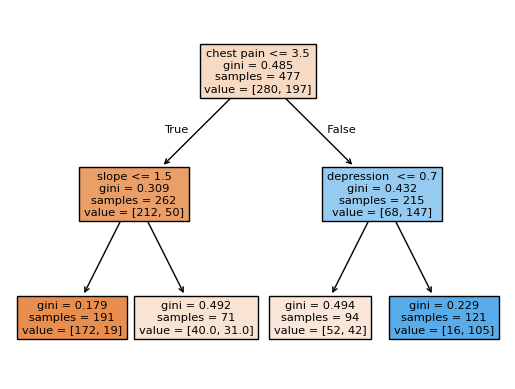

In [ ]:
from sklearn.tree import plot_tree

DTP = DecisionTreeClassifier(max_depth=2, random_state=72)
DTP.fit(Xtrain, Ytrain)

plot_tree(DTP, feature_names=df.columns, filled=True);

**Tree Hyperparameters**

In [ ]:
DT = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced"
)

**Hyperparameter Analysis**

In [ ]:
hp_max=72

result=[]

for i in range(1,hp_max):

    DT=DecisionTreeClassifier(max_depth=i)
    DT.fit(Xtrain,Ytrain)
    result.append([i, accuracy_score(Ytrain,DT.predict(Xtrain)),accuracy_score(Ytest,DT.predict(Xtest))])


for depth, tr, te in result[:5]:
    print(f"Depth={depth}, Train Acc={tr:.3f}, Test Acc={te:.3f}")

Depth=1, Train Acc=0.753, Test Acc=0.850
Depth=2, Train Acc=0.774, Test Acc=0.858
Depth=3, Train Acc=0.828, Test Acc=0.817
Depth=4, Train Acc=0.855, Test Acc=0.808
Depth=5, Train Acc=0.889, Test Acc=0.783


**Plot the Results**

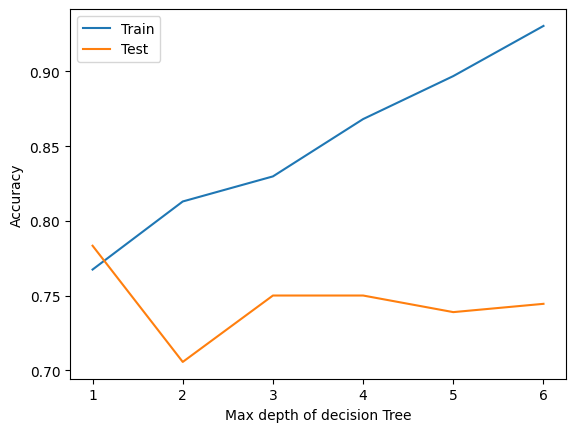

In [ ]:
tf.plot(kind='line',xlabel='Max depth of decision Tree',ylabel='Accuracy');